<a href="https://colab.research.google.com/github/pantera-rosa/vuln-management-capstone/blob/jacqueline-branch/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [24]:
import os
import json
import subprocess
import requests
import pandas as pd
!pip install flatten_json
from flatten_json import flatten
from collections import defaultdict
import matplotlib.pyplot as plt

In [17]:
def json_to_pandas_df(data_json):
  # Attempt to convert the JSON data to a pandas DataFrame by flattening it
  try:
      data_json_flat = flatten(data_json)
      df = pd.DataFrame([data_json_flat]) # Wrap the flattened dictionary in a list
      display(df)
      return df
  except Exception as e:
      print(f"Error flattening and converting JSON to DataFrame: {e}")
      print("The JSON data might still be too complex or have inconsistent structures for full flattening.\n Consider manually extracting specific nested paths using json_normalize or exploring the JSON structure directly.")

In [67]:
def plot_hist(dictionary, x_label, y_label, title, sort=True, include_bar_labels=True):
  # Convert the dictionary to a pandas Series for easier plotting
  series = pd.Series(dictionary)

  # Sort the series by index
  if sort:
    series = series.sort_index()

  # Create a bar plot
  plt.figure(figsize=(12, 6))
  ax = series.plot(kind='bar')
  if include_bar_labels:
    for container in ax.containers:
      ax.bar_label(container, fmt='%g', label_type='edge', padding=3)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)
  plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels overlapping
  plt.show()

## CVE Records

View 1 record:

In [5]:
# Construct the URL for the CVE data in the cvelistv5 GitHub repository
cve_id = "CVE-2019-1010218"
year = cve_id.split('-')[1] # Extract the year from the CVE ID
id_prefix = cve_id.split('-')[2][:-3] # Extract the all but the last 3 digits of the id from the CVE ID

In [13]:
# The structure of the cvelistv5 repo is cves/{year}/{id_prefix}xxx/{cve_id}.json
cvelist_url = f"https://raw.githubusercontent.com/CVEProject/cvelistV5/refs/heads/main/cves/{year}/{id_prefix}xxx/{cve_id}.json"

# Use the requests library to fetch and parse the data
cvelist_data_json = requests.get(cvelist_url).json()

# Display the fetched data
if cvelist_data_json:
    display(cvelist_data_json)
else:
    print(f"Could not fetch or parse data for {cve_id} from cvelistv5.")

{'containers': {'cna': {'affected': [{'product': 'Latest Cherokee Web server',
     'vendor': 'Cherokee Webserver',
     'versions': [{'status': 'affected',
       'version': "Upto Version 1.2.103 (Current stable) [fixed: There's no fix yet]"}]}],
   'descriptions': [{'lang': 'en',
     'value': "Cherokee Webserver Latest Cherokee Web server Upto Version 1.2.103 (Current stable) is affected by: Buffer Overflow - CWE-120. The impact is: Crash. The component is: Main cherokee command. The attack vector is: Overwrite argv[0] to an insane length with execl. The fixed version is: There's no fix yet."}],
   'problemTypes': [{'descriptions': [{'cweId': 'CWE-120',
       'description': 'Buffer Overflow - CWE-120',
       'lang': 'en',
       'type': 'CWE'}]}],
   'providerMetadata': {'dateUpdated': '2019-07-22T17:30:25',
    'orgId': '7556d962-6fb7-411e-85fa-6cd62f095ba8',
    'shortName': 'dwf'},
   'references': [{'tags': ['x_refsource_MISC'],
     'url': 'https://i.imgur.com/PWCCyir.png'}],

In [18]:
cvelist_df = json_to_pandas_df(cvelist_data_json)

,containers_cna_affected_0_product,containers_cna_affected_0_vendor,containers_cna_affected_0_versions_0_status,containers_cna_affected_0_versions_0_version,containers_cna_descriptions_0_lang,containers_cna_descriptions_0_value,containers_cna_problemTypes_0_descriptions_0_cweId,containers_cna_problemTypes_0_descriptions_0_description,containers_cna_problemTypes_0_descriptions_0_lang,containers_cna_problemTypes_0_descriptions_0_type,...,containers_adp_0_references_0_url,cveMetadata_assignerOrgId,cveMetadata_assignerShortName,cveMetadata_cveId,cveMetadata_datePublished,cveMetadata_dateReserved,cveMetadata_dateUpdated,cveMetadata_state,dataType,dataVersion
0,Latest Cherokee Web server,Cherokee Webserver,affected,Upto Version 1.2.103 (Current stable) [fixed: ...,en,Cherokee Webserver Latest Cherokee Web server ...,CWE-120,Buffer Overflow - CWE-120,en,CWE,...,https://i.imgur.com/PWCCyir.png,7556d962-6fb7-411e-85fa-6cd62f095ba8,dwf,CVE-2019-1010218,2019-07-22T17:30:25,2019-03-20T00:00:00,2024-08-05T03:07:18.468Z,PUBLISHED,CVE_RECORD,5.1


Count records:\
Due to GitHub API request limitations, results are incomplete.

In [27]:
# GitHub API: get repo tree (recursive).
url = "https://api.github.com/repos/CVEProject/cvelistV5/git/trees/main?recursive=1"
exclude_files = {"delta.json", "deltaLog.json"}

resp = requests.get(url)
resp.raise_for_status()
data = resp.json()

total_count = 0
by_year = defaultdict(int)

for item in data.get("tree", []):
    if item["type"] == "blob" and item["path"].startswith("cves/"):
        filename = item["path"].split("/")[-1]
        if filename not in exclude_files:
            total_count += 1

            # check if path has "cves/YYYY/"
            parts = item["path"].split("/")
            if len(parts) > 1 and parts[1].isdigit():
                year = parts[1]
                by_year[year] += 1

print("Total CVE leaf files:", total_count)
print("\nCounts by year:")
for year in sorted(by_year.keys()):
    print(year, by_year[year])

Total CVE leaf files: 77106

Counts by year:
1999 1579
2000 1242
2001 1556
2002 2393
2003 1555
2004 2707
2005 4769
2006 7143
2007 6580
2008 7177
2009 5052
2010 5244
2011 4886
2012 5937
2013 6819
2014 9000
2015 3467


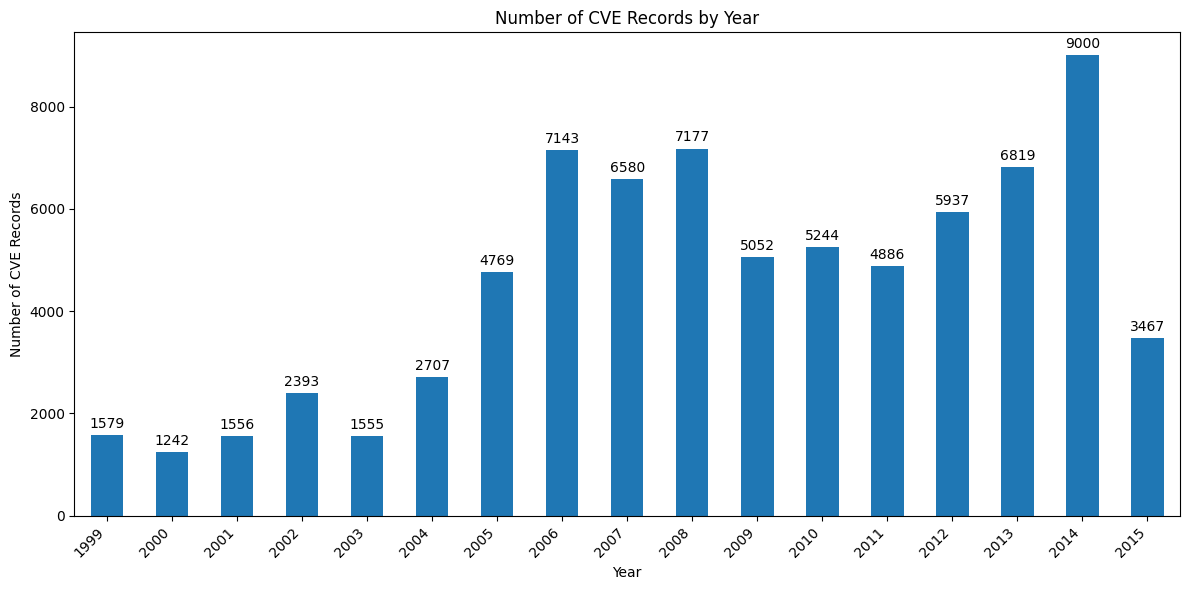

In [68]:
plot_hist(by_year, 'Year', 'Number of CVE Records', 'Number of CVE Records by Year')

Count from local machine:

```
$ git ls-files cves/ | grep -E '[0-9]+\/.*CVE-.*json' | wc -l
310441
```





```
$ git ls-files cves | \
>   grep -vE 'delta\.json$|deltaLog\.json$' | \
>   awk -F/ '{print $2}' | \
>   sort | uniq -c | \
>   awk '{print "\""$2"\": "$1","}' | \
>   sed '$ s/,$//' | \
>   awk 'BEGIN{print "{"} {print} END{print "}"}'
{
"1999": 1579,
"2000": 1242,
"2001": 1556,
"2002": 2393,
"2003": 1555,
"2004": 2707,
"2005": 4769,
"2006": 7143,
"2007": 6580,
"2008": 7177,
"2009": 5052,
"2010": 5244,
"2011": 4886,
"2012": 5937,
"2013": 6819,
"2014": 9000,
"2015": 8766,
"2016": 10560,
"2017": 17023,
"2018": 17495,
"2019": 17082,
"2020": 20640,
"2021": 23095,
"2022": 26863,
"2023": 30077,
"2024": 38664,
"2025": 26537
}
```



In [76]:
by_year = {
"1999": 1579,
"2000": 1242,
"2001": 1556,
"2002": 2393,
"2003": 1555,
"2004": 2707,
"2005": 4769,
"2006": 7143,
"2007": 6580,
"2008": 7177,
"2009": 5052,
"2010": 5244,
"2011": 4886,
"2012": 5937,
"2013": 6819,
"2014": 9000,
"2015": 8766,
"2016": 10560,
"2017": 17023,
"2018": 17495,
"2019": 17082,
"2020": 20640,
"2021": 23095,
"2022": 26863,
"2023": 30077,
"2024": 38664,
"2025": 26537
}

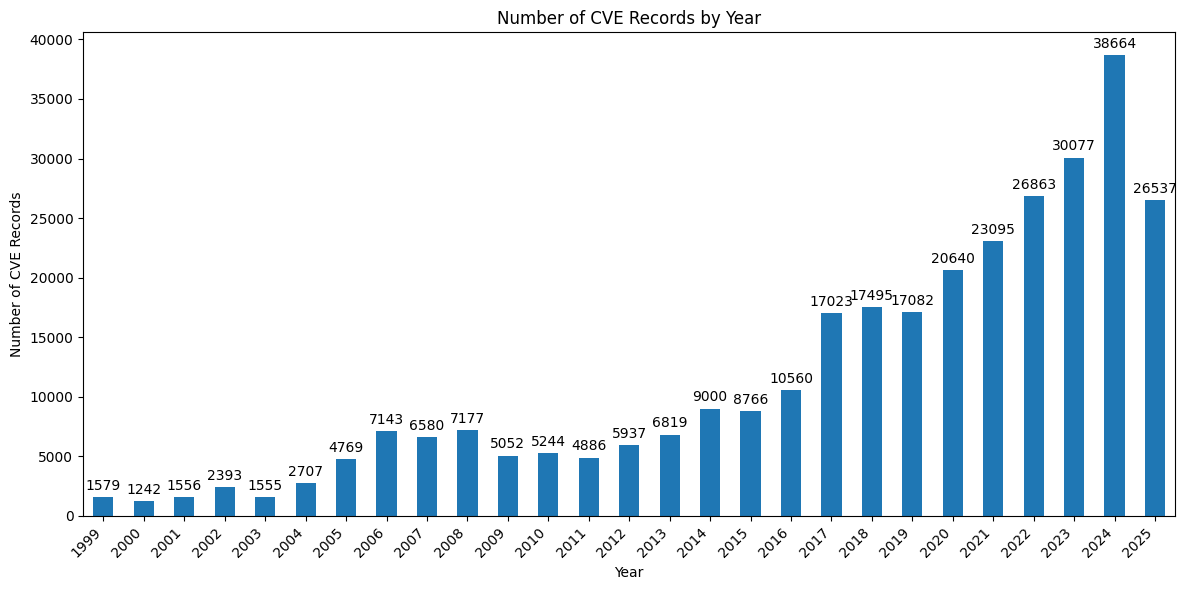

In [77]:
plot_hist(by_year, 'Year', 'Number of CVE Records', 'Number of CVE Records by Year')

## NVD Data Feeds

View 1 record:

In [15]:
nvd_url = f"https://services.nvd.nist.gov/rest/json/cves/2.0?cveId=CVE-2019-1010218"

In [16]:
nvd_data_json = requests.get(nvd_url).json()
nvd_data_json

{'resultsPerPage': 1,
 'startIndex': 0,
 'totalResults': 1,
 'format': 'NVD_CVE',
 'version': '2.0',
 'timestamp': '2025-09-18T03:35:47.999',
 'vulnerabilities': [{'cve': {'id': 'CVE-2019-1010218',
    'sourceIdentifier': 'josh@bress.net',
    'published': '2019-07-22T18:15:10.917',
    'lastModified': '2024-11-21T04:18:03.857',
    'vulnStatus': 'Modified',
    'cveTags': [],
    'descriptions': [{'lang': 'en',
      'value': "Cherokee Webserver Latest Cherokee Web server Upto Version 1.2.103 (Current stable) is affected by: Buffer Overflow - CWE-120. The impact is: Crash. The component is: Main cherokee command. The attack vector is: Overwrite argv[0] to an insane length with execl. The fixed version is: There's no fix yet."},
     {'lang': 'es',
      'value': 'El servidor web de Cherokee más reciente de Cherokee Webserver Hasta Versión 1.2.103 (estable actual) está afectado por: Desbordamiento de Búfer - CWE-120. El impacto es: Bloqueo. El componente es: Comando cherokee principal.

In [28]:
nvd_df = json_to_pandas_df(nvd_data_json)

,resultsPerPage,startIndex,totalResults,format,version,timestamp,vulnerabilities_0_cve_id,vulnerabilities_0_cve_sourceIdentifier,vulnerabilities_0_cve_published,vulnerabilities_0_cve_lastModified,...,vulnerabilities_0_cve_configurations_0_nodes_0_cpeMatch_0_versionEndIncluding,vulnerabilities_0_cve_configurations_0_nodes_0_cpeMatch_0_matchCriteriaId,vulnerabilities_0_cve_references_0_url,vulnerabilities_0_cve_references_0_source,vulnerabilities_0_cve_references_0_tags_0,vulnerabilities_0_cve_references_0_tags_1,vulnerabilities_0_cve_references_1_url,vulnerabilities_0_cve_references_1_source,vulnerabilities_0_cve_references_1_tags_0,vulnerabilities_0_cve_references_1_tags_1
0,1,0,1,NVD_CVE,2.0,2025-09-18T03:35:47.999,CVE-2019-1010218,josh@bress.net,2019-07-22T18:15:10.917,2024-11-21T04:18:03.857,...,1.2.103,DCE1E311-F9E5-4752-9F51-D5DA78B7BBFA,https://i.imgur.com/PWCCyir.png,josh@bress.net,Exploit,Third Party Advisory,https://i.imgur.com/PWCCyir.png,af854a3a-2127-422b-91ae-364da2661108,Exploit,Third Party Advisory


Count records:

In [56]:
total_nvd_count = requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&resultsPerPage=1").json()["totalResults"]
total_nvd_count

294527

In [57]:
cvssV2Severity_counts = {
    'LOW': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV2Severity=LOW&resultsPerPage=1").json()["totalResults"],
    'MEDIUM': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV2Severity=MEDIUM&resultsPerPage=1").json()["totalResults"],
    'HIGH': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV2Severity=HIGH&resultsPerPage=1").json()["totalResults"]
}
cvssV2Severity_counts['UNSCORED'] = total_nvd_count - sum(cvssV2Severity_counts.values())

In [58]:
cvssV3Severity_counts = {
    'LOW': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=LOW&resultsPerPage=1").json()["totalResults"],
    'MEDIUM': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=MEDIUM&resultsPerPage=1").json()["totalResults"],
    'HIGH': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=HIGH&resultsPerPage=1").json()["totalResults"],
    'CRITICAL': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV3Severity=CRITICAL&resultsPerPage=1").json()["totalResults"]
}
cvssV3Severity_counts['UNSCORED'] = total_nvd_count - sum(cvssV3Severity_counts.values())

In [63]:
requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=CRITICAL&resultsPerPage=1").json()["totalResults"]

6

In [64]:
cvssV4Severity_counts = {
    'LOW': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=LOW&resultsPerPage=1").json()["totalResults"],
    'MEDIUM': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=MEDIUM&resultsPerPage=1").json()["totalResults"],
    'HIGH': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=HIGH&resultsPerPage=1").json()["totalResults"],
    'CRITICAL': requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cvssV4Severity=CRITICAL&resultsPerPage=1").json()["totalResults"]
}
cvssV4Severity_counts['UNSCORED'] = total_nvd_count - sum(cvssV4Severity_counts.values())

In [73]:
cveTag_counts = {
    "disputed": requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cveTag=disputed&resultsPerPage=1").json()["totalResults"],
    "unsupported-when-assigned": requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cveTag=unsupported-when-assigned&resultsPerPage=1").json()["totalResults"],
    "exclusively-hosted-service": requests.get("https://services.nvd.nist.gov/rest/json/cves/2.0?noRejected&cveTag=exclusively-hosted-service&resultsPerPage=1").json()["totalResults"],
}
#cveTag_counts['untagged'] = total_nvd_count - sum(cveTag_counts.values())

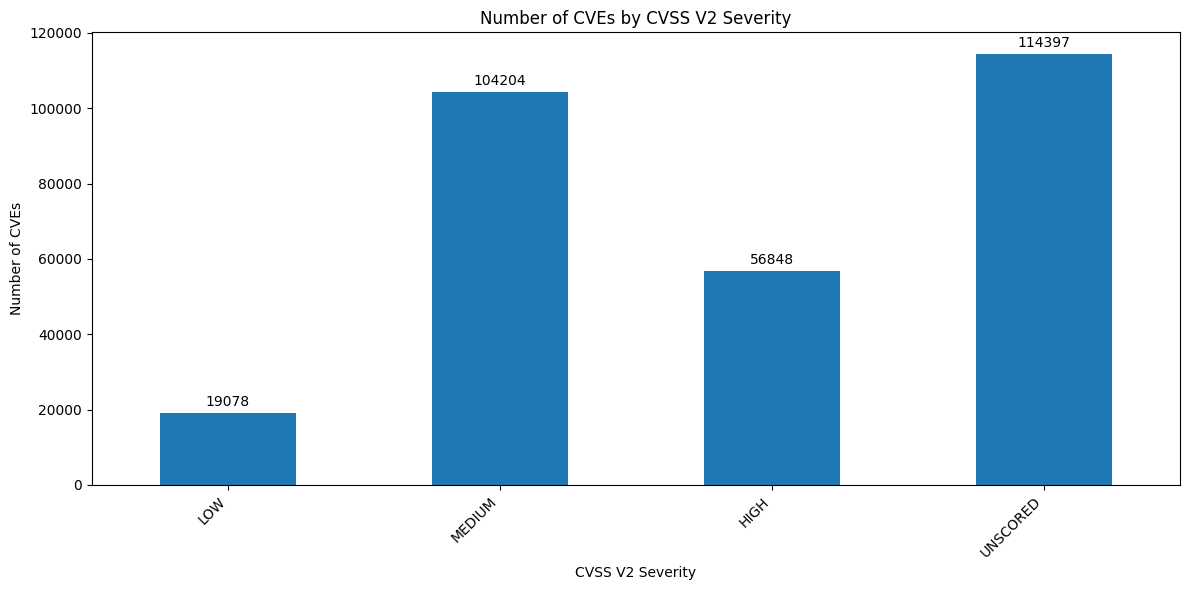

In [69]:
plot_hist(cvssV2Severity_counts, "CVSS V2 Severity", "Number of CVEs", "Number of CVEs by CVSS V2 Severity", sort=False)

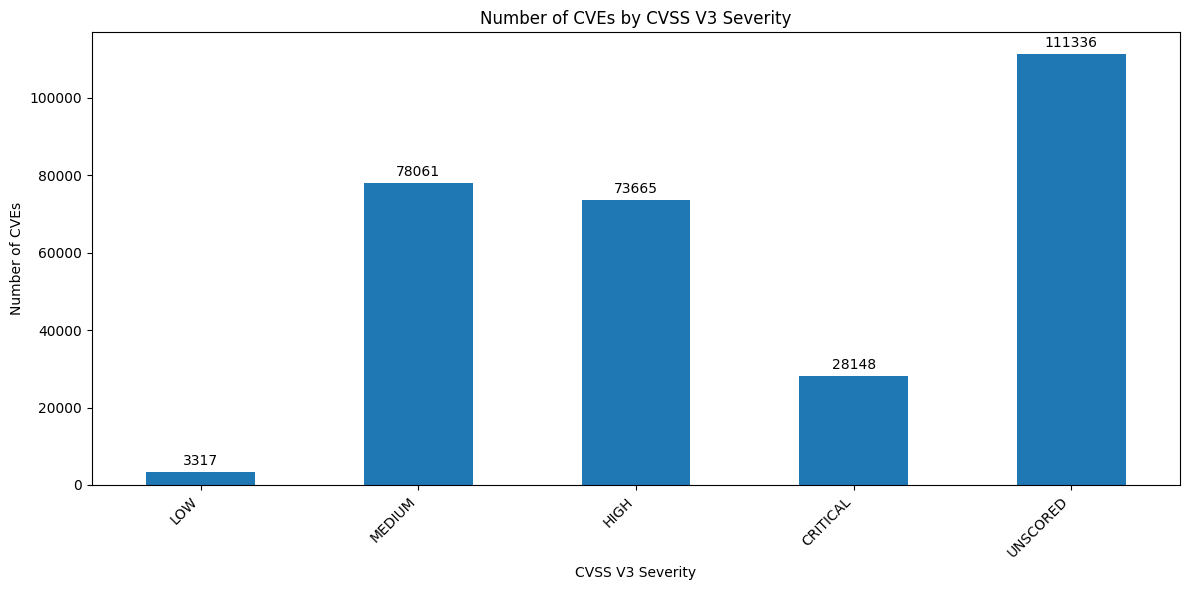

In [70]:
plot_hist(cvssV3Severity_counts, "CVSS V3 Severity", "Number of CVEs", "Number of CVEs by CVSS V3 Severity", sort=False)

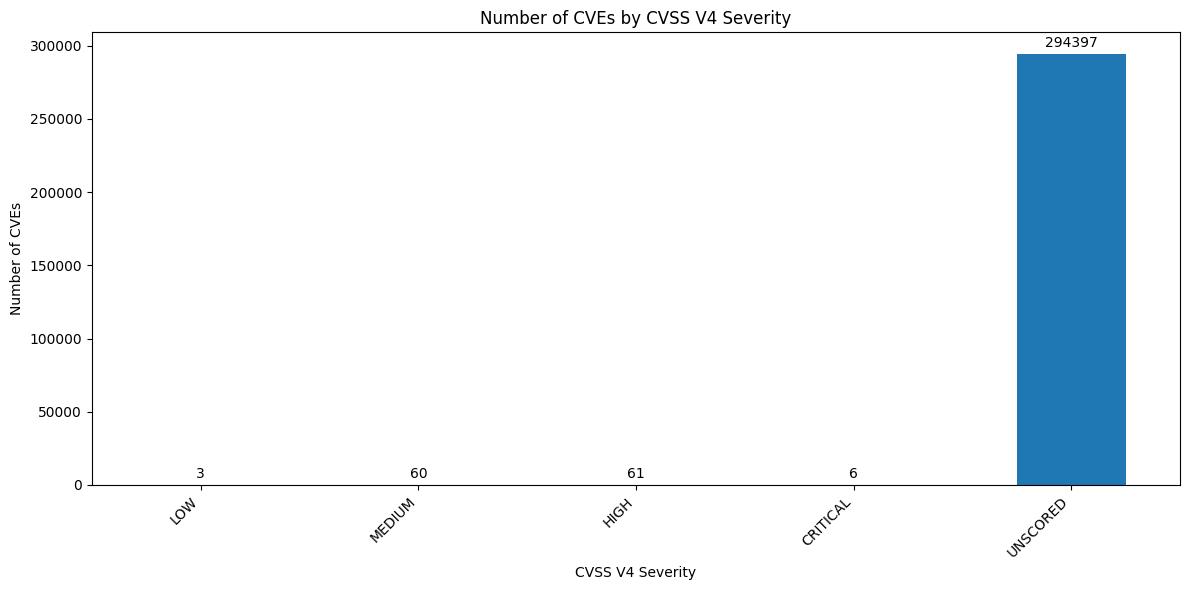

In [71]:
plot_hist(cvssV4Severity_counts, "CVSS V4 Severity", "Number of CVEs", "Number of CVEs by CVSS V4 Severity", sort=False)

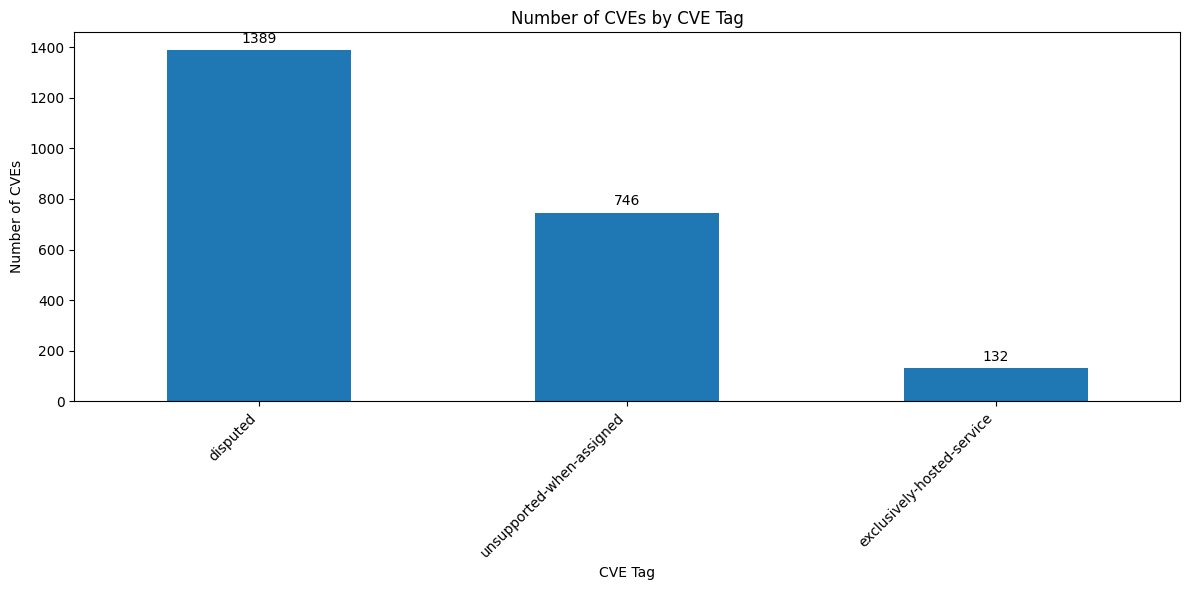

In [74]:
plot_hist(cveTag_counts, "CVE Tag", "Number of CVEs", "Number of CVEs by CVE Tag", sort=False)

## EPSS Data

In [19]:
epss_url = "https://api.first.org/data/v1/epss?cve=CVE-2019-1010218"

In [21]:
epss_data_json = requests.get(epss_url).json()
epss_data_json

{'status': 'OK',
 'status-code': 200,
 'version': '1.0',
 'access': 'public',
 'total': 1,
 'offset': 0,
 'limit': 100,
 'data': [{'cve': 'CVE-2019-1010218',
   'epss': '0.006240000',
   'percentile': '0.692680000',
   'date': '2025-09-17'}]}

## Additional Data Sources